In [12]:
#1.Given a CSV file containing Zomato restaurant ratings, use pandas to detect outliers in the 'user_rating'
# column using the IQR method and print the indices of the detected outliers.
import pandas as pd 

data=pd.read_csv("zomato.csv")

Q1=data["user_rating"].quantile(0.25)
Q3=data["user_rating"].quantile(0.75)

IQR=Q3-Q1

lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

outliers=data[
    (data["user_rating"]<lower_limit)|
    (data["user_rating"]>upper_limit)
]

print("outlier indices:")
print(outliers.index)

outlier indices:
RangeIndex(start=7, stop=21, step=7)


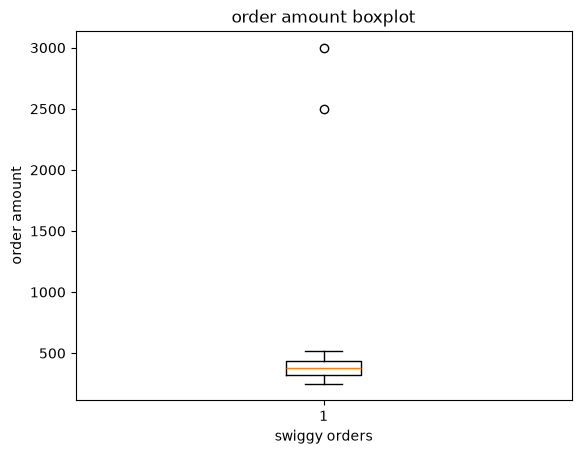

In [18]:
#2.Create a boxplot for the 'order_amount' column from a Swiggy orders dataset using matplotlib, and visually
# identify any outliers present.<br><br><em><strong>Hint:</strong> Use plt.boxplot() and label your axes for clarity.</em>
import pandas as pd
import matplotlib.pyplot as plt

data=pd.read_csv("swiggy.csv")

plt.boxplot(data["order_amount"])

plt.xlabel("swiggy orders")
plt.ylabel("order amount")
plt.title("order amount boxplot")

plt.show()


In [21]:
#3.Apply winsorization to the 'transaction_amount' column in a Paytm transactions DataFrame to cap all values
# above the 95th percentile and below the 5th percentile, then display the updated column statistics.
import pandas as pd

data = pd.read_csv("paytm_data.csv")

lower = data["transaction_amount"].quantile(0.05)
upper = data["transaction_amount"].quantile(0.95)

data["transaction_amount"] = data["transaction_amount"].clip(
    lower=lower,
    upper=upper
)

print("ppdated transaction amount statistics:")
print(data["transaction_amount"].describe())

ppdated transaction amount statistics:
count       20.000000
mean      1909.325000
std       2968.519329
min        116.500000
25%        487.500000
50%        950.000000
75%       1650.000000
max      10750.000000
Name: transaction_amount, dtype: float64


In [29]:
#4.You have a DataFrame of Flipkart product prices stored as strings with currency symbols (e.g., '₹1,299'). Convert this
# column to numeric type using pandas, ensuring all non-numeric characters are removed.<br><br><em><strong>Hint:</strong> Use str.replace() and astype().</em>
import pandas as pd

data = pd.DataFrame({
    "price": ["₹1,299", "₹2,499", "₹999", "₹5,000"]
})

data["price"] = data["price"].str.replace("₹", "")
data["price"] = data["price"].str.replace(",", "")
data["price"] = data["price"].astype(int)

print(data)
print(data.dtypes)

   price
0   1299
1   2499
2    999
3   5000
price    int64
dtype: object


In [31]:
#5.Fix the following code snippet where the 'is_premium' column in a Spotify user DataFrame is a mix of boolean,
# string, and integer types. Convert the entire column to boolean type, treating 'True', 1, and 'yes' as True, and everything else as False.
import pandas as pd

data = pd.DataFrame({
    "is_premium": [True, "True", 1, "yes", False, "False", 0, "no"]
})

data["is_premium"] = data["is_premium"].apply(
    lambda x: True if x in [True, "True", 1, "yes"] else False
)

print(data)
print(data.dtypes)

   is_premium
0        True
1        True
2        True
3        True
4       False
5       False
6       False
7       False
is_premium    bool
dtype: object
